In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv('Student_Performance.csv')
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes':1,'No':0})
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype(int)
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


<Axes: >

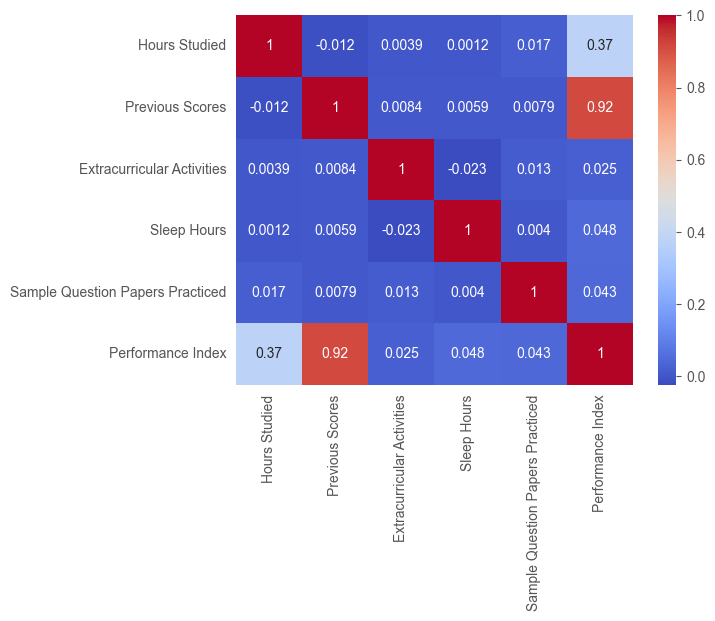

In [68]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [71]:
X_train = df[['Hours Studied', 'Previous Scores']].values
y_train = df['Performance Index'].values

print(X_train.shape, y_train.shape)

(10000, 2) (10000,)


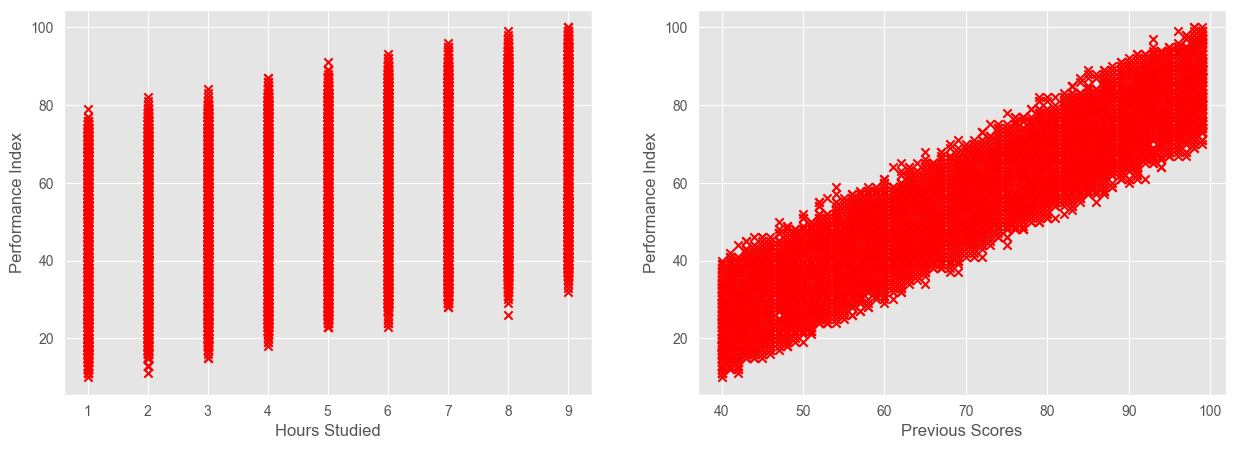

In [82]:
plt.style.use('ggplot')

fig, axs = plt.subplots(1,2, figsize=(15,5))

axs[0].scatter(X_train[:,0], y_train, marker='x', c='red')
axs[0].set_xlabel('Hours Studied')
axs[0].set_ylabel('Performance Index')

axs[1].scatter(X_train[:,1], y_train, marker='x', c='red')
axs[1].set_xlabel('Previous Scores')
axs[1].set_ylabel('Performance Index')

plt.show()

In [100]:
def predict(X,W,b):
    return np.dot(X,W) + b
x_train = X_train[0,:]
w = np.array([0.5, 0.5])
b = 0
print(x_train)
print(predict(x_train, w, b))
print("Loss: ", (predict(x_train, w, b) - y_train[0]) ** 2)

[ 7 99]
53.0
Loss:  1444.0


In [93]:
def compute_model_output(X, W, b):
    m = X.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = np.dot(X[i],W) + b
    return f_wb

In [94]:
print(X_train.shape[1], y_train.shape)

2 (10000,)


ValueError: x and y must be the same size

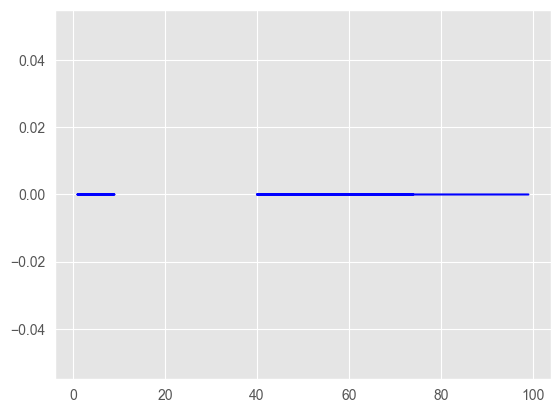

In [95]:
W = np.zeros(X_train.shape[1])
b = 0
tmp_f_wb = compute_model_output(X_train, W, b)
plt.plot(X_train, tmp_f_wb, c='b',label='Our Prediction')
plt.scatter(X_train, y_train, marker='x', c='red')
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [26]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb- y[i]) ** 2
        cost_sum = cost_sum + cost

    total_cost = (1 / (2 * m)) * cost_sum
    return total_cost


In [27]:
def compute_gradient(x, y, w, b):

    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b

        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]

        dj_db += dj_db_i
        dj_dw += dj_dw_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [28]:
def gradient_descent(x, y, alpha, iterations):
    w, b = 0, 0
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 1000 == 0:
            print(f"Iteration: {i+1}, Cost: {compute_cost(x, y, w, b)}")
    print(f"w: {w}, b: {b}")
    return w, b

In [29]:
learning_rate = 0.01
iterations = 10000

w, b = gradient_descent(x_train, y_train, learning_rate, iterations)
tmp_f_wb = compute_model_output(x_train, w, b)


Iteration: 1, Cost: 1344612525.8413548
Iteration: 1001, Cost: 16523106.110673292
Iteration: 2001, Cost: 15648329.194311943
Iteration: 3001, Cost: 15635661.98387988
Iteration: 4001, Cost: 15635478.556291511
Iteration: 5001, Cost: 15635475.900167624
Iteration: 6001, Cost: 15635475.861705618
Iteration: 7001, Cost: 15635475.861148665
Iteration: 8001, Cost: 15635475.861140601
Iteration: 9001, Cost: 15635475.861140486
w: 9449.962323709777, b: 25792.20018347487


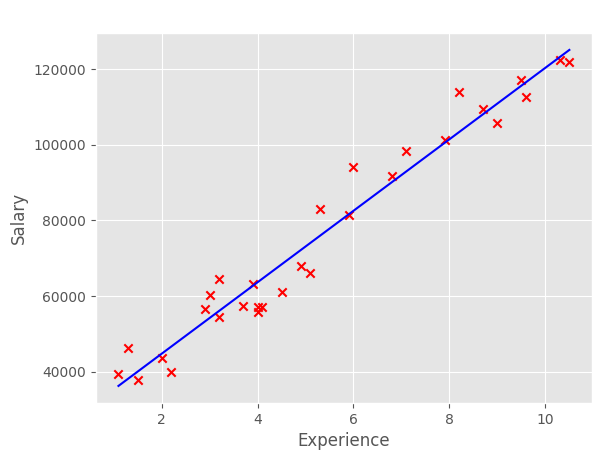

In [30]:
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='red')
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()